In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install beautifulsoup4 openpyxl lxml scipy seaborn adjustText -q

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 2 — Check folder structure
# ============================================================
import os

base_path = '/content/drive/MyDrive/comp6910/gke'
print(f"Base path exists: {os.path.exists(base_path)}")
print("\nFolders found:")
for f in sorted(os.listdir(base_path)):
    full = os.path.join(base_path, f)
    if os.path.isdir(full):
        files = os.listdir(full)
        html = [x for x in files if x.endswith('.html')]
        print(f"  📁 {f}/ → HTML: {html}")
    else:
        print(f"  📄 {f}")

Base path exists: True

Folders found:
  📄 HPA_Single_gke.txt
  📄 HPA_multi_gke.txt
  📁 experiment-50-multi-100users/ → HTML: ['Locust_2026-04-03-14h37_locustfile.py_http___34.16.84.88.html']
  📁 experiment-50-multi-300users/ → HTML: ['Locust_2026-04-03-15h04_locustfile.py_http___34.16.84.88.html']
  📁 experiment-50-multi-500users/ → HTML: ['Locust_2026-04-03-15h35_locustfile.py_http___34.16.84.88.html']
  📁 experiment-50-single-100users/ → HTML: ['Locust_2026-04-02-13h51_locustfile.py_http___34.16.84.88.html']
  📁 experiment-50-single-300users/ → HTML: ['Locust_2026-04-02-14h20_locustfile.py_http___34.16.84.88.html']
  📁 experiment-50-single-500users/ → HTML: ['Locust_2026-04-02-14h48_locustfile.py_http___34.16.84.88.html']
  📁 experiment-70-multi-100users/ → HTML: ['Locust_2026-04-03-16h07_locustfile.py_http___34.16.84.88.html']
  📁 experiment-70-multi-300users/ → HTML: ['Locust_2026-04-03-16h40_locustfile.py_http___34.16.84.88.html']
  📁 experiment-70-multi-500users/ → HTML: ['Locus

In [ ]:
# ============================================================
# CELL 2 — Parse GKE HTML reports
# ============================================================
import os, json, re
import pandas as pd

def extract_metrics(html_path):
    with open(html_path, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    idx = content.find('"Aggregated"')
    if idx == -1:
        return None
    start = content.rfind('{', 0, idx)
    end = content.find('}', idx) + 1
    try:
        stat = json.loads(content[start:end])
    except:
        return None
    num_req  = stat.get('num_requests', 0)
    num_fail = stat.get('num_failures', 0)
    return {
        'avg_response_time':    round(stat.get('avg_response_time', 0), 1),
        'median_response_time': stat.get('median_response_time', 0),
        'p95_response_time':    stat.get('response_time_percentile_0.95', 0),
        'p99_response_time':    stat.get('response_time_percentile_0.99', 0),
        'max_response_time':    stat.get('max_response_time', 0),
        'total_rps':            round(stat.get('total_rps', 0), 2),
        'total_requests':       num_req,
        'total_failures':       num_fail,
        'failure_rate':         round(num_fail/num_req*100, 2) if num_req > 0 else 0,
    }

base_path = '/content/drive/MyDrive/comp6910/gke'
rows = []

for folder in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, folder)
    if not os.path.isdir(folder_path):
        continue
    m = re.match(r'^experiment-(\d+)-(single|multi)-(\d+)users$', folder)
    if not m:
        print(f"⏭️  Skipping: {folder}")
        continue
    threshold, scope, users = m.groups()
    html_files = [f for f in os.listdir(folder_path) if f.endswith('.html')]
    if not html_files:
        print(f"❌ No HTML: {folder}")
        continue
    metrics = extract_metrics(os.path.join(folder_path, html_files[0]))
    if metrics:
        rows.append({
            'Threshold (%)':             int(threshold),
            'Scope':                     scope.title(),
            'Users':                     int(users),
            'Avg Response Time (ms)':    metrics['avg_response_time'],
            'Median Response Time (ms)': metrics['median_response_time'],
            'P95 Response Time (ms)':    metrics['p95_response_time'],
            'P99 Response Time (ms)':    metrics['p99_response_time'],
            'Max Response Time (ms)':    metrics['max_response_time'],
            'RPS':                       metrics['total_rps'],
            'Total Requests':            metrics['total_requests'],
            'Total Failures':            metrics['total_failures'],
            'Failure Rate (%)':          metrics['failure_rate'],
        })
        print(f"✅ {folder}")
    else:
        print(f"❌ Failed: {folder}")

gke_df = pd.DataFrame(rows)
gke_df = gke_df.sort_values(['Threshold (%)', 'Scope', 'Users']).reset_index(drop=True)
print(f"\nTotal: {len(gke_df)} GKE experiments loaded")
print(gke_df[['Threshold (%)','Scope','Users','Avg Response Time (ms)','Failure Rate (%)']].to_string())

✅ experiment-50-multi-100users
✅ experiment-50-multi-300users
✅ experiment-50-multi-500users
✅ experiment-50-single-100users
✅ experiment-50-single-300users
✅ experiment-50-single-500users
✅ experiment-70-multi-100users
✅ experiment-70-multi-300users
✅ experiment-70-multi-500users
✅ experiment-70-single-100users
✅ experiment-70-single-300users
✅ experiment-70-single-500users
✅ experiment-85-multi-100users
✅ experiment-85-multi-300users
✅ experiment-85-multi-500users
✅ experiment-85-single-100users
✅ experiment-85-single-300users
✅ experiment-85-single-500users

Total: 18 GKE experiments loaded
    Threshold (%)   Scope  Users  Avg Response Time (ms)  Failure Rate (%)
0              50   Multi    100                   295.5              0.00
1              50   Multi    300                  1675.9              0.00
2              50   Multi    500                  4467.4              0.00
3              50  Single    100                   299.1              0.00
4              50  Singl

In [ ]:
import re

def parse_single_hpa_gke(filepath):
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    section_starts = []
    for i, line in enumerate(lines):
        m = re.match(r'(100|300|500)\s+[Uu]sers?\s+(\d+)%\s+HPA', line.strip())
        if m:
            section_starts.append((i, m.group(1), m.group(2)))
    def get_max(section_lines):
        max_pods = 1; peak_cpu = 0
        for line in section_lines:
            cols = line.split()
            if len(cols) >= 7 and 'frontend' in cols[0]:
                try:
                    replicas = int(cols[6])
                    max_pods = max(max_pods, replicas)
                    cpu = float(cols[3].replace('cpu:','').split('/')[0].replace('%',''))
                    peak_cpu = max(peak_cpu, cpu)
                except: pass
        return max_pods, peak_cpu
    results = {}
    for si, (start, users, threshold) in enumerate(section_starts):
        end = section_starts[si+1][0] if si+1 < len(section_starts) else len(lines)
        mp, pc = get_max(lines[start:end])
        results[(int(threshold), 'Single', int(users))] = {'max_pods': mp, 'peak_cpu': pc}
    return results

def parse_multi_hpa_gke(filepath):
    with open(filepath, 'rb') as f:
        raw = f.read()
    lines = raw.decode('utf-8', errors='replace').splitlines()
    section_starts = []
    for i, line in enumerate(lines):
        m = re.match(r'(100|300|500)\s+[Uu]sers?\s+(\d+)%\s+HPA', line.strip())
        if m:
            section_starts.append((i, m.group(1), m.group(2)))
    def get_max(section_lines):
        svc = {'frontend':1,'cart':1,'checkout':1,'recommendation':1}
        peak_cpu = 0
        for line in section_lines:
            cols = line.split()
            if len(cols) >= 7 and '-hpa' in cols[0]:
                try:
                    replicas = int(cols[6])
                    cpu = float(cols[3].replace('cpu:','').split('/')[0].replace('%',''))
                    peak_cpu = max(peak_cpu, cpu)
                    for s in svc:
                        if s in cols[0]:
                            svc[s] = max(svc[s], replicas)
                except: pass
        return sum(svc.values()), peak_cpu
    results = {}
    for si, (start, users, threshold) in enumerate(section_starts):
        end = section_starts[si+1][0] if si+1 < len(section_starts) else len(lines)
        mp, pc = get_max(lines[start:end])
        results[(int(threshold), 'Multi', int(users))] = {'max_pods': mp, 'peak_cpu': pc}
    return results

single_hpa_gke = parse_single_hpa_gke('/content/drive/MyDrive/comp6910/gke/HPA_Single_gke.txt')
multi_hpa_gke  = parse_multi_hpa_gke('/content/drive/MyDrive/comp6910/gke/HPA_multi_gke.txt')
all_hpa_gke    = {**single_hpa_gke, **multi_hpa_gke}

print(f"Loaded {len(all_hpa_gke)} GKE HPA experiments")
for (t,s,u), v in sorted(all_hpa_gke.items()):
    print(f"{t}% {s:<8} {u}u → {v['max_pods']} pods, {v['peak_cpu']:.0f}% peak CPU")

Loaded 18 GKE HPA experiments
50% Multi    100u → 8 pods, 192% peak CPU
50% Multi    300u → 9 pods, 199% peak CPU
50% Multi    500u → 9 pods, 199% peak CPU
50% Single   100u → 4 pods, 158% peak CPU
50% Single   300u → 4 pods, 143% peak CPU
50% Single   500u → 4 pods, 199% peak CPU
70% Multi    100u → 7 pods, 166% peak CPU
70% Multi    300u → 7 pods, 200% peak CPU
70% Multi    500u → 7 pods, 157% peak CPU
70% Single   100u → 3 pods, 185% peak CPU
70% Single   300u → 3 pods, 191% peak CPU
70% Single   500u → 3 pods, 152% peak CPU
85% Multi    100u → 7 pods, 195% peak CPU
85% Multi    300u → 7 pods, 200% peak CPU
85% Multi    500u → 7 pods, 194% peak CPU
85% Single   100u → 3 pods, 196% peak CPU
85% Single   300u → 3 pods, 172% peak CPU
85% Single   500u → 3 pods, 200% peak CPU


In [ ]:
# ============================================================
# CELL 4 — Build GKE final_df with new cost model
# ============================================================
# NEW GKE COST MODEL
# 3 nodes × $0.067/node/hr + $0.10 cluster fee = $0.301/hr total
# Per pod = $0.301 / active_pods → average $0.01/pod/hr

COST_PER_POD_GKE = 0.01  # USD per pod per hour
duration_map = {50: 20/60, 70: 20/60, 85: 20/60}

rows = []
for _, row in gke_df.iterrows():
    t = row['Threshold (%)']; s = row['Scope']; u = row['Users']
    hpa = all_hpa_gke.get((t, s, u), {'max_pods': 1, 'peak_cpu': 0})
    cost = round(hpa['max_pods'] * duration_map[t] * COST_PER_POD_GKE, 4)
    rows.append({
        'Threshold (%)':             t,
        'Scope':                     s,
        'Users':                     u,
        'Avg Response Time (ms)':    row['Avg Response Time (ms)'],
        'Median Response Time (ms)': row['Median Response Time (ms)'],
        'P95 Response Time (ms)':    row['P95 Response Time (ms)'],
        'P99 Response Time (ms)':    row['P99 Response Time (ms)'],
        'Max Response Time (ms)':    row['Max Response Time (ms)'],
        'RPS':                       row['RPS'],
        'Total Requests':            row['Total Requests'],
        'Total Failures':            row['Total Failures'],
        'Failure Rate (%)':          row['Failure Rate (%)'],
        'Max Pods':                  hpa['max_pods'],
        'Peak CPU (%)':              hpa['peak_cpu'],
        'Estimated Cost (USD)':      cost,
        'Environment':               'GKE',
    })

gke_final_df = pd.DataFrame(rows)
gke_final_df = gke_final_df.sort_values(['Threshold (%)', 'Scope', 'Users']).reset_index(drop=True)
print(f"✅ GKE final_df: {len(gke_final_df)} rows")
print(gke_final_df[['Threshold (%)','Scope','Users','Avg Response Time (ms)','Max Pods','Failure Rate (%)','Estimated Cost (USD)']].to_string())

✅ GKE final_df: 18 rows
    Threshold (%)   Scope  Users  Avg Response Time (ms)  Max Pods  Failure Rate (%)  Estimated Cost (USD)
0              50   Multi    100                   295.5         8              0.00                0.0267
1              50   Multi    300                  1675.9         9              0.00                0.0300
2              50   Multi    500                  4467.4         9              0.00                0.0300
3              50  Single    100                   299.1         4              0.00                0.0133
4              50  Single    300                  1823.4         4              0.00                0.0133
5              50  Single    500                  4185.6         4              0.00                0.0133
6              70   Multi    100                   315.6         7              0.00                0.0233
7              70   Multi    300                  1938.7         7              0.00                0.0233
8            

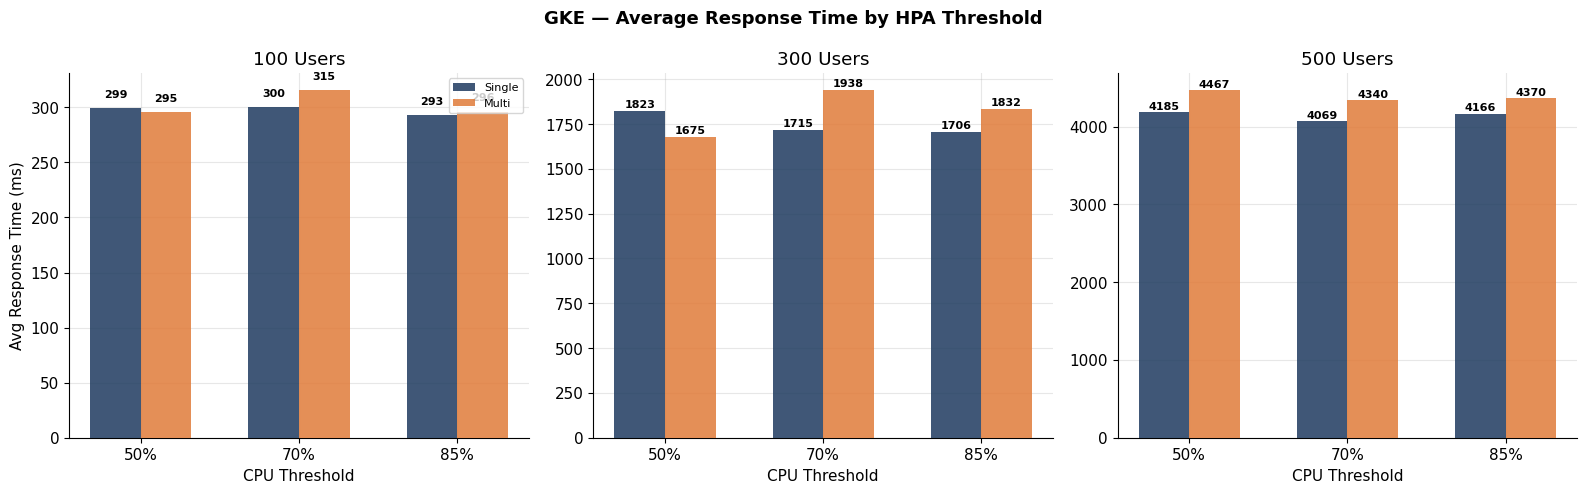

✅ GKE Graph 1

🎉 All 7 GKE graphs saved!


In [ ]:
# ============================================================
# CELL 5 — GKE Graphs (same 7 graphs)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from adjustText import adjust_text
from numpy.polynomial.polynomial import polyfit
from scipy import stats
import os

os.makedirs('/content/graphs_gke', exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.facecolor': 'white', 'figure.facecolor': 'white',
})

C = {50: '#2563EB', 70: '#16A34A', 85: '#DC2626'}
S_COLOR = '#1E3A5F'; M_COLOR = '#E07B39'; GRAY = '#6B7280'
thresholds = [50, 70, 85]; user_levels = [100, 300, 500]; scopes = ['Single', 'Multi']
df = gke_final_df  # alias

def add_labels(ax, bars, offset=3):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+offset, f'{int(h)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# G1: Response Time
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('GKE — Average Response Time by HPA Threshold', fontsize=13, fontweight='bold')
for col, users in enumerate(user_levels):
    ax = axes[col]; x = np.arange(3); w = 0.32
    sv = [df[(df['Threshold (%)']==t)&(df['Scope']=='Single')&(df['Users']==users)]['Avg Response Time (ms)'].values[0] for t in thresholds]
    mv = [df[(df['Threshold (%)']==t)&(df['Scope']=='Multi') &(df['Users']==users)]['Avg Response Time (ms)'].values[0] for t in thresholds]
    b1 = ax.bar(x-w/2, sv, w, label='Single', color=S_COLOR, alpha=0.85, zorder=3)
    b2 = ax.bar(x+w/2, mv, w, label='Multi',  color=M_COLOR, alpha=0.85, zorder=3)
    add_labels(ax, b1, offset=8); add_labels(ax, b2, offset=8)
    ax.set_title(f'{users} Users'); ax.set_xticks(x)
    ax.set_xticklabels([f'{t}%' for t in thresholds]); ax.set_xlabel('CPU Threshold')
    if col==0: ax.set_ylabel('Avg Response Time (ms)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/graphs_gke/g1_response_time.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ GKE Graph 1")


print("\n🎉 All 7 GKE graphs saved!")

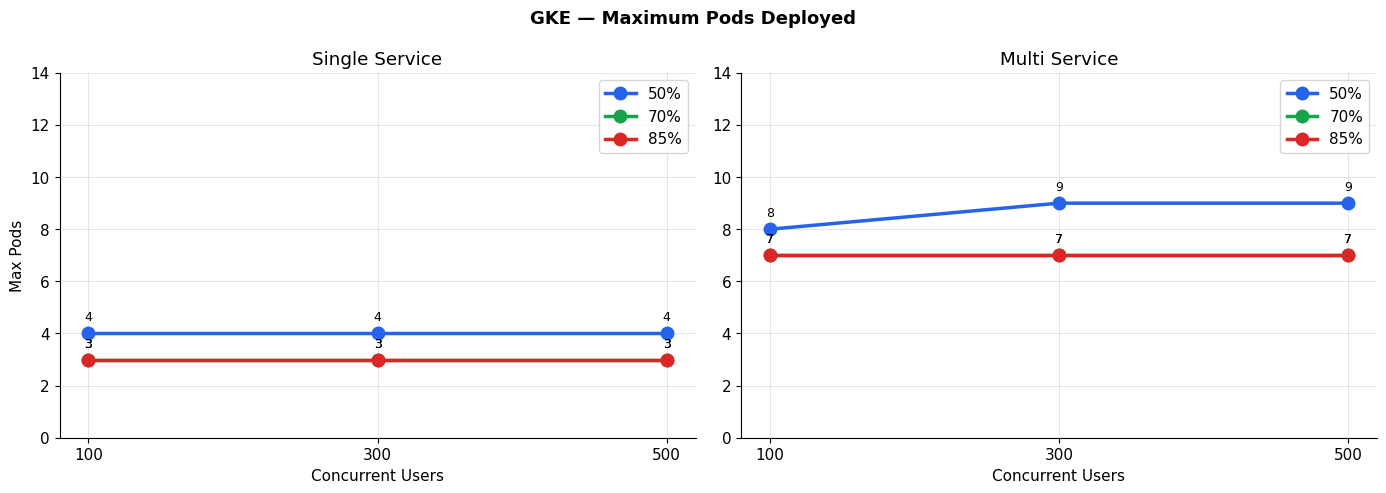

✅ GKE Graph 2


In [ ]:
# G2: Max Pods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GKE — Maximum Pods Deployed', fontsize=13, fontweight='bold')
for col, scope in enumerate(scopes):
    ax = axes[col]
    for t in thresholds:
        pods = [df[(df['Threshold (%)']==t)&(df['Scope']==scope)&(df['Users']==u)]['Max Pods'].values[0] for u in user_levels]
        ax.plot(user_levels, pods, marker='o', linewidth=2.5, markersize=9, label=f'{t}%', color=C[t])
        for u, p in zip(user_levels, pods):
            ax.annotate(f'{p}', (u,p), xytext=(0,9), textcoords='offset points', ha='center', fontsize=9)
    ax.set_title(f'{scope} Service'); ax.set_xticks(user_levels)
    ax.set_xlabel('Concurrent Users')
    if col==0: ax.set_ylabel('Max Pods')
    ax.legend(); ax.set_ylim(0,14)
plt.tight_layout()
plt.savefig('/content/graphs_gke/g2_max_pods.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ GKE Graph 2")



In [ ]:
print(df['Threshold (%)'].unique())

for scope in scopes:
    print(f"\n--- {scope} ---")
    for t in thresholds:
        pods = [
            df[(df['Threshold (%)']==t)&(df['Scope']==scope)&(df['Users']==u)]['Max Pods'].values[0]
            for u in user_levels
        ]
        print(f"{t}%:", pods)

[50 70 85]

--- Single ---
50%: [np.int64(4), np.int64(4), np.int64(4)]
70%: [np.int64(3), np.int64(3), np.int64(3)]
85%: [np.int64(3), np.int64(3), np.int64(3)]

--- Multi ---
50%: [np.int64(8), np.int64(9), np.int64(9)]
70%: [np.int64(7), np.int64(7), np.int64(7)]
85%: [np.int64(7), np.int64(7), np.int64(7)]


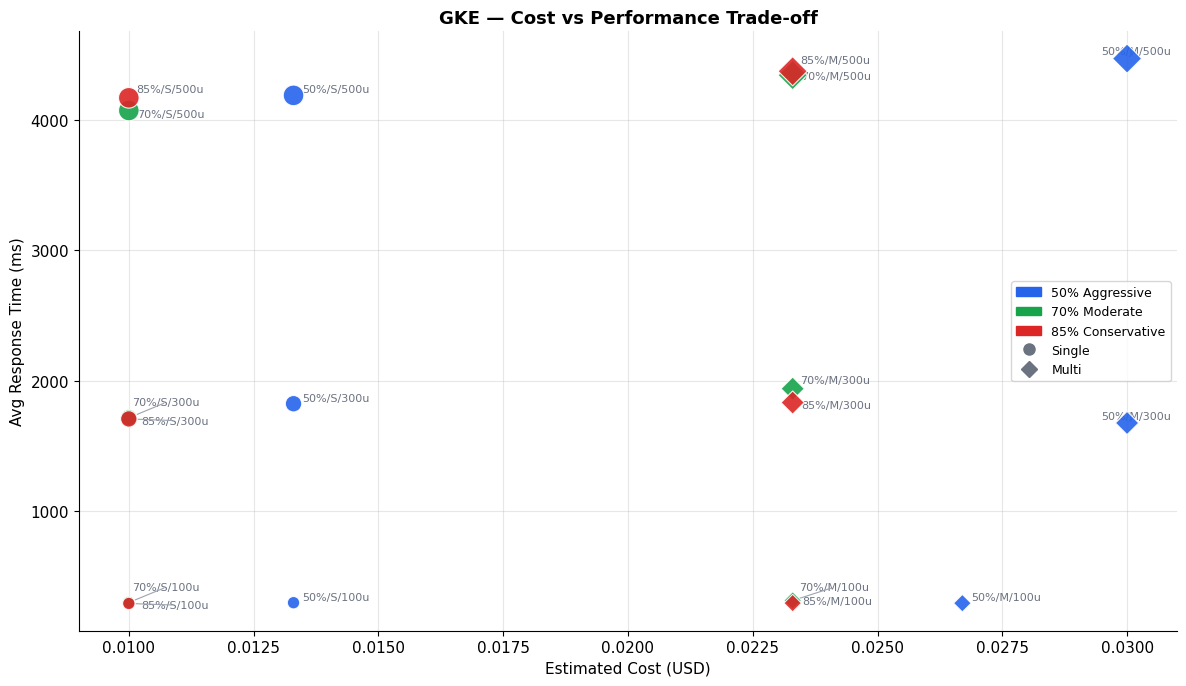

✅ GKE Graph 3


In [ ]:
# G3: Cost vs Performance
fig, ax = plt.subplots(figsize=(12, 7))
texts = []
for t in thresholds:
    for scope, mk in [('Single','o'),('Multi','D')]:
        sub = df[(df['Threshold (%)']==t)&(df['Scope']==scope)]
        sizes = {100:80,300:140,500:220}
        ax.scatter(sub['Estimated Cost (USD)'], sub['Avg Response Time (ms)'],
                  c=C[t], marker=mk, s=[sizes[u] for u in sub['Users']],
                  alpha=0.9, zorder=5, edgecolors='white', linewidths=0.8)
        for _, row in sub.iterrows():
            texts.append(ax.text(row['Estimated Cost (USD)'], row['Avg Response Time (ms)'],
                         f"{t}%/{scope[0]}/{row['Users']}u", fontsize=8, color=GRAY))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='#9CA3AF', lw=0.8), expand_points=(1.5,1.5))
legend_els = [
    mpatches.Patch(color=C[50], label='50% Aggressive'),
    mpatches.Patch(color=C[70], label='70% Moderate'),
    mpatches.Patch(color=C[85], label='85% Conservative'),
    plt.Line2D([0],[0], marker='o', color=GRAY, linestyle='None', markersize=8, label='Single'),
    plt.Line2D([0],[0], marker='D', color=GRAY, linestyle='None', markersize=8, label='Multi'),
]
ax.legend(handles=legend_els, fontsize=9)
ax.set_xlabel('Estimated Cost (USD)'); ax.set_ylabel('Avg Response Time (ms)')
ax.set_title('GKE — Cost vs Performance Trade-off', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/graphs_gke/g3_cost_vs_performance.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ GKE Graph 3")


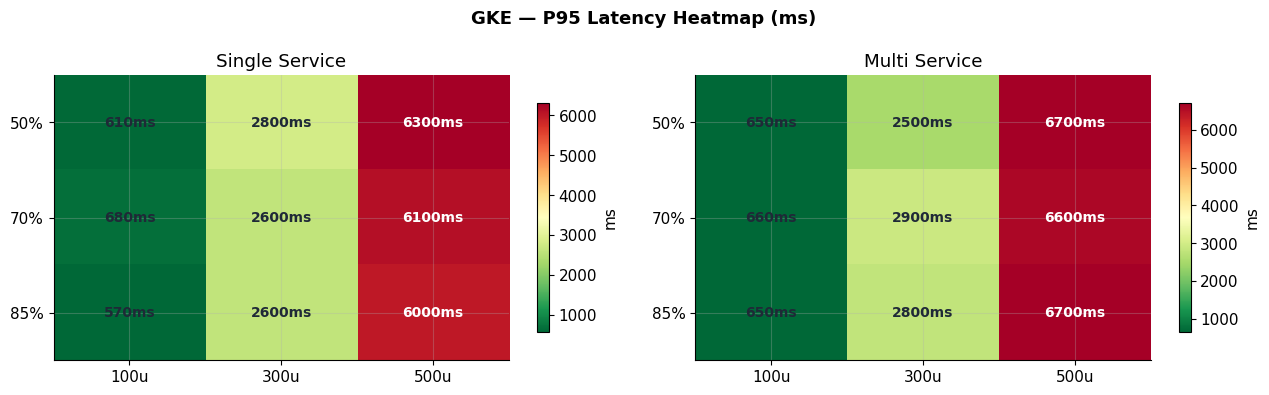

✅ GKE Graph 4


In [ ]:
# G4: P95 Heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('GKE — P95 Latency Heatmap (ms)', fontsize=13, fontweight='bold')
for col, scope in enumerate(scopes):
    ax = axes[col]
    matrix = np.array([[df[(df['Threshold (%)']==t)&(df['Scope']==scope)&(df['Users']==u)]['P95 Response Time (ms)'].values[0] for u in user_levels] for t in thresholds], dtype=float)
    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
    plt.colorbar(im, ax=ax, label='ms', shrink=0.8)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels([f'{u}u' for u in user_levels])
    ax.set_yticklabels([f'{t}%' for t in thresholds])
    ax.set_title(f'{scope} Service')
    for i in range(3):
        for j in range(3):
            v = matrix[i,j]
            ax.text(j, i, f'{int(v)}ms', ha='center', va='center', fontsize=10, fontweight='bold',
                   color='white' if v > matrix.max()*0.6 else '#1F2937')
plt.tight_layout()
plt.savefig('/content/graphs_gke/g4_p95_heatmap.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ GKE Graph 4")



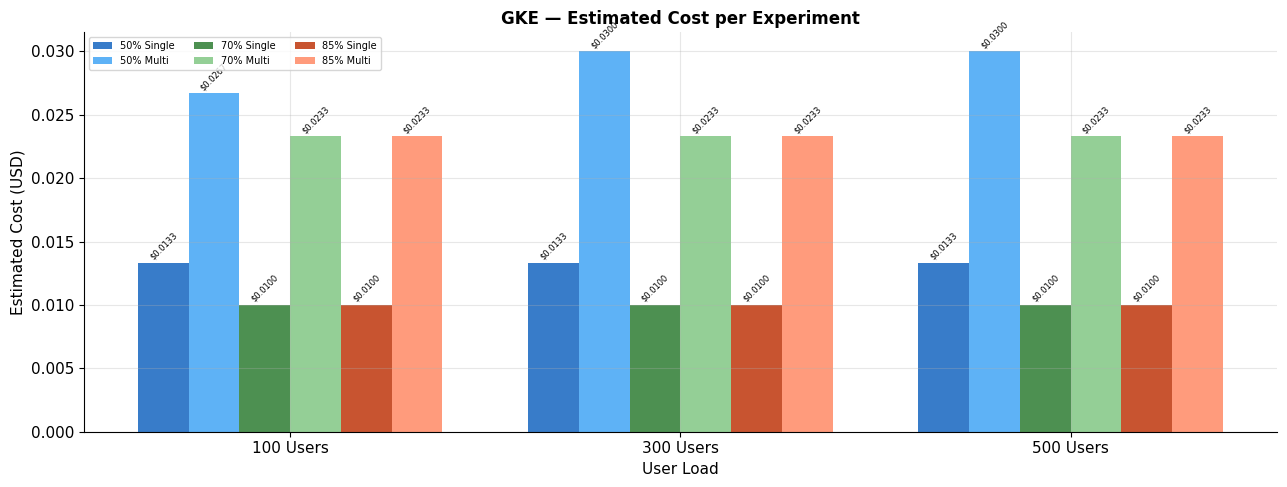

✅ GKE Graph 5


In [ ]:
# G5: Cost Comparison
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(3); w = 0.13
offsets = np.linspace(-2.5, 2.5, 6)*w
colors6 = ['#1565C0','#42A5F5','#2E7D32','#81C784','#BF360C','#FF8A65']
labels6 = [f'{t}% {s}' for t in thresholds for s in ['Single','Multi']]
for idx, (t, scope) in enumerate([(t,s) for t in thresholds for s in ['Single','Multi']]):
    costs = [df[(df['Threshold (%)']==t)&(df['Scope']==scope)&(df['Users']==u)]['Estimated Cost (USD)'].values[0] for u in user_levels]
    bars = ax.bar(x+offsets[idx], costs, w, label=labels6[idx], color=colors6[idx], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.0001, f'${h:.4f}', ha='center', va='bottom', fontsize=6, rotation=45)
ax.set_xlabel('User Load'); ax.set_ylabel('Estimated Cost (USD)')
ax.set_title('GKE — Estimated Cost per Experiment', fontsize=12, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'{u} Users' for u in user_levels])
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.savefig('/content/graphs_gke/g5_cost_comparison.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ GKE Graph 5")



/tmp/ipykernel_27201/151491781.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot([df[df['Threshold (%)']==t]['Avg Response Time (ms)'] for t in thresholds],


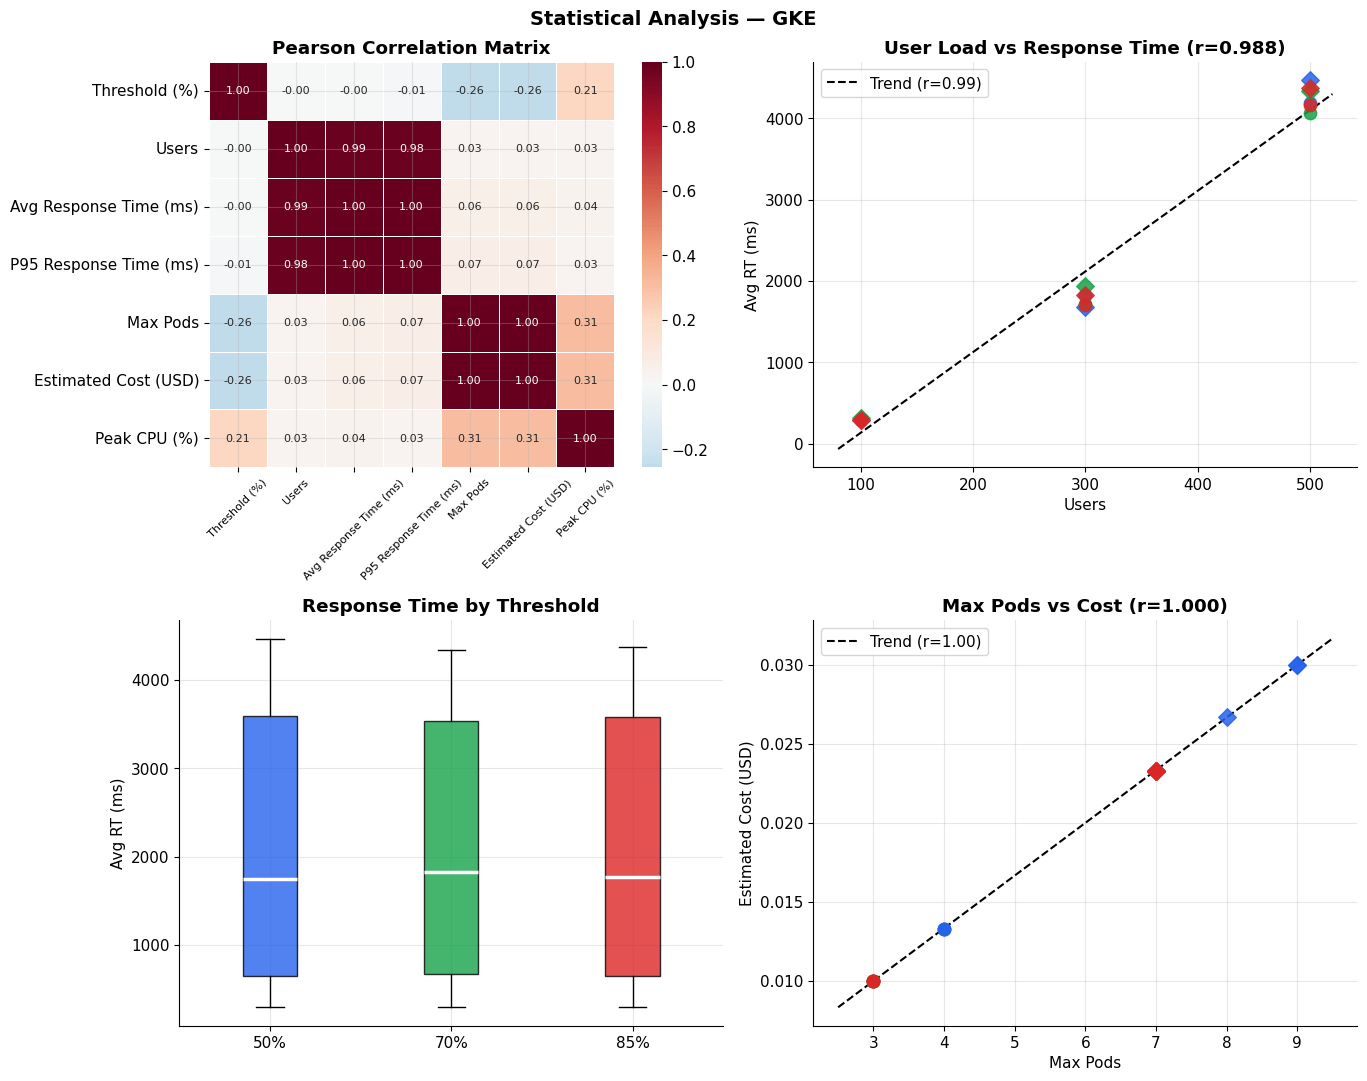

✅ GKE Graph 6


In [ ]:
# G6: Statistical
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Statistical Analysis — GKE', fontsize=14, fontweight='bold')
corr_cols = ['Threshold (%)','Users','Avg Response Time (ms)','P95 Response Time (ms)','Max Pods','Estimated Cost (USD)','Peak CPU (%)']
corr_matrix_gke = df[corr_cols].corr()
sns.heatmap(corr_matrix_gke, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0,0], square=True, annot_kws={'size':8}, linewidths=0.5)
axes[0,0].set_title('Pearson Correlation Matrix', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45, labelsize=8)

ax2 = axes[0,1]
for t in thresholds:
    for scope, mk in [('Single','o'),('Multi','D')]:
        sub = df[(df['Threshold (%)']==t)&(df['Scope']==scope)]
        ax2.scatter(sub['Users'], sub['Avg Response Time (ms)'], c=C[t], marker=mk, s=80, alpha=0.85, zorder=5)
b, m_coef = polyfit(df['Users'].values, df['Avg Response Time (ms)'].values, 1)
x_line = np.linspace(80,520,100)
r_gke, _ = stats.pearsonr(df['Users'], df['Avg Response Time (ms)'])
ax2.plot(x_line, b+m_coef*x_line, 'k--', linewidth=1.5, label=f'Trend (r={r_gke:.2f})')
ax2.set_xlabel('Users'); ax2.set_ylabel('Avg RT (ms)')
ax2.set_title(f'User Load vs Response Time (r={r_gke:.3f})', fontweight='bold'); ax2.legend()

ax3 = axes[1,0]
bp = ax3.boxplot([df[df['Threshold (%)']==t]['Avg Response Time (ms)'] for t in thresholds],
                  labels=['50%','70%','85%'], patch_artist=True,
                  medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], list(C.values())):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax3.set_ylabel('Avg RT (ms)'); ax3.set_title('Response Time by Threshold', fontweight='bold')

ax4 = axes[1,1]
for t in thresholds:
    for scope, mk in [('Single','o'),('Multi','D')]:
        sub = df[(df['Threshold (%)']==t)&(df['Scope']==scope)]
        ax4.scatter(sub['Max Pods'], sub['Estimated Cost (USD)'], c=C[t], marker=mk, s=80, alpha=0.85, zorder=5)
b2, m2 = polyfit(df['Max Pods'].values, df['Estimated Cost (USD)'].values, 1)
x_line2 = np.linspace(df['Max Pods'].min()-0.5, df['Max Pods'].max()+0.5, 100)
r2_gke, _ = stats.pearsonr(df['Max Pods'], df['Estimated Cost (USD)'])
ax4.plot(x_line2, b2+m2*x_line2, 'k--', linewidth=1.5, label=f'Trend (r={r2_gke:.2f})')
ax4.set_xlabel('Max Pods'); ax4.set_ylabel('Estimated Cost (USD)')
ax4.set_title(f'Max Pods vs Cost (r={r2_gke:.3f})', fontweight='bold'); ax4.legend()
plt.tight_layout()
plt.savefig('/content/graphs_gke/g6_statistical.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ GKE Graph 6")



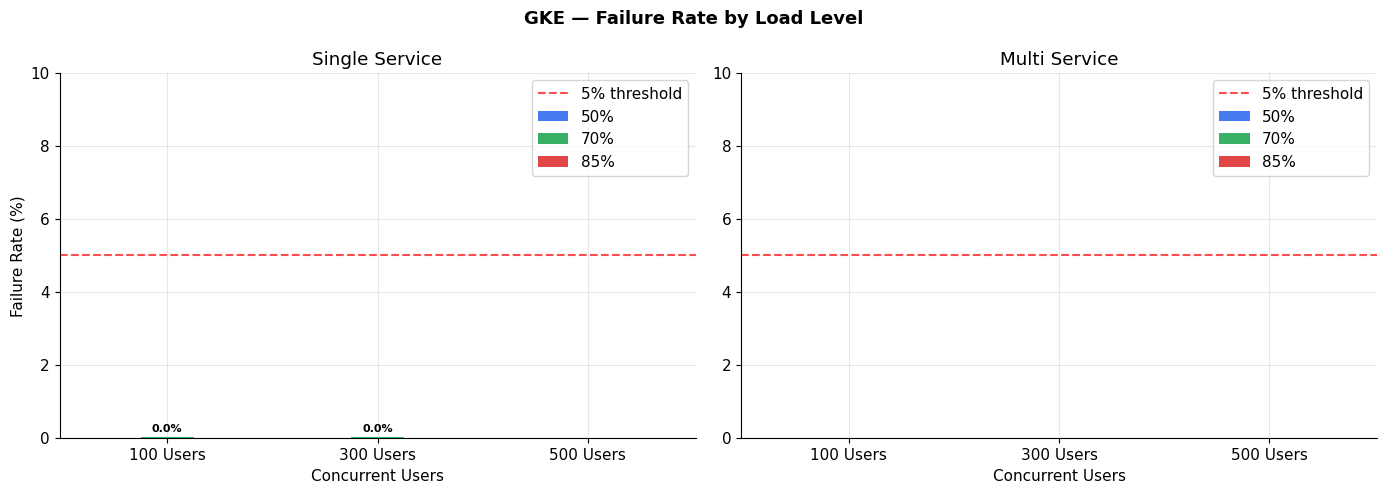

✅ GKE Graph 7


In [ ]:
# G7: Failure Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GKE — Failure Rate by Load Level', fontsize=13, fontweight='bold')
for col, scope in enumerate(scopes):
    ax = axes[col]; x = np.arange(3); w = 0.25
    for i, t in enumerate(thresholds):
        rates = [df[(df['Threshold (%)']==t)&(df['Scope']==scope)&(df['Users']==u)]['Failure Rate (%)'].values[0] for u in user_levels]
        bars = ax.bar(x+(i-1)*w, rates, w, label=f'{t}%', color=C[t], alpha=0.85, zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x()+bar.get_width()/2, h+0.1, f'{h:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(y=5, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='5% threshold')
    ax.set_title(f'{scope} Service'); ax.set_xlabel('Concurrent Users')
    if col==0: ax.set_ylabel('Failure Rate (%)')
    ax.set_xticks(x); ax.set_xticklabels([f'{u} Users' for u in user_levels])
    ax.legend(); ax.set_ylim(0, 10)
plt.tight_layout()
plt.savefig('/content/graphs_gke/g7_failure_rate.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ GKE Graph 7")

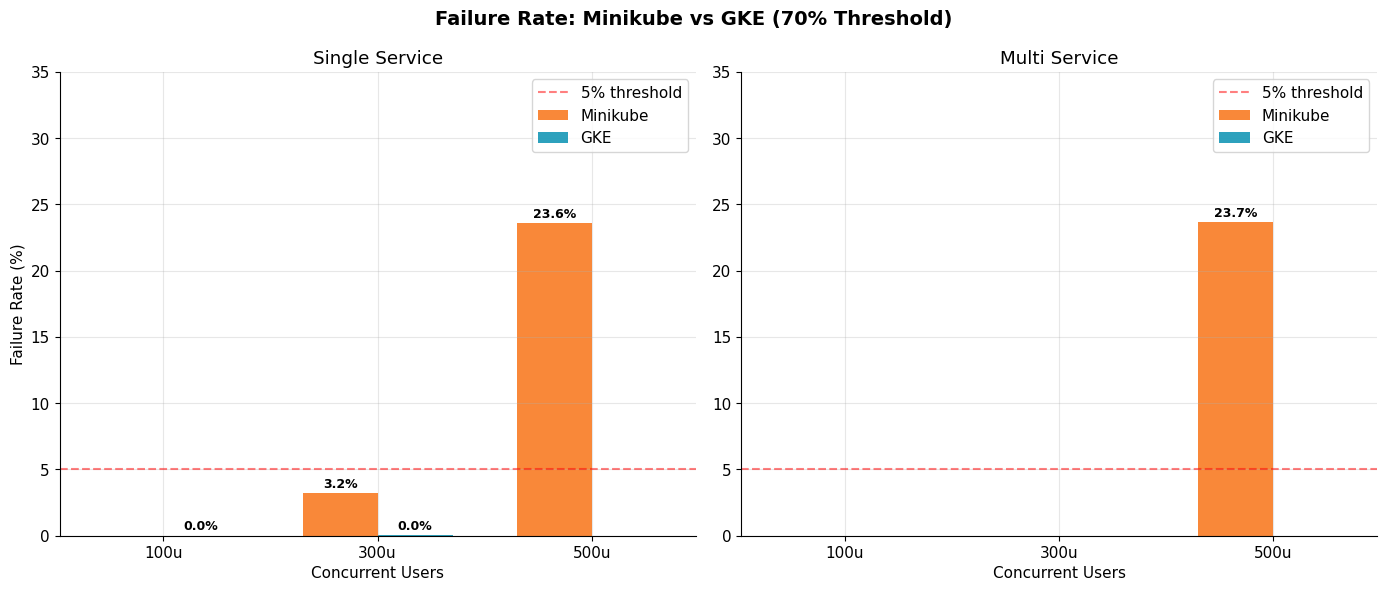

✅ Comparison 1

🎉 All comparison graphs saved!


In [ ]:
# ============================================================
# CELL 6 — GKE vs Minikube Comparison Graphs
# ============================================================
# NOTE: Run this AFTER running Minikube notebook
# Load Minikube results from Excel first
minikube_df = pd.read_excel('/content/drive/MyDrive/comp6910/minikube_results.xlsx')
minikube_df['Environment'] = 'Minikube'

ENV_C = {'Minikube': '#F97316', 'GKE': '#0891B2'}
os.makedirs('/content/graphs_comparison', exist_ok=True)

# Comparison 1: Failure Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Failure Rate: Minikube vs GKE (70% Threshold)', fontsize=14, fontweight='bold')
for col, scope in enumerate(scopes):
    ax = axes[col]; x = np.arange(3); w = 0.35
    mink = [minikube_df[(minikube_df['Threshold (%)']==70)&(minikube_df['Scope']==scope)&(minikube_df['Users']==u)]['Failure Rate (%)'].values[0] for u in user_levels]
    gke  = [gke_final_df[(gke_final_df['Threshold (%)']==70)&(gke_final_df['Scope']==scope)&(gke_final_df['Users']==u)]['Failure Rate (%)'].values[0] for u in user_levels]
    b1 = ax.bar(x-w/2, mink, w, label='Minikube', color=ENV_C['Minikube'], alpha=0.85)
    b2 = ax.bar(x+w/2, gke,  w, label='GKE',      color=ENV_C['GKE'],      alpha=0.85)
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
    ax.set_title(f'{scope} Service'); ax.set_xlabel('Concurrent Users')
    if col==0: ax.set_ylabel('Failure Rate (%)')
    ax.set_xticks(x); ax.set_xticklabels([f'{u}u' for u in user_levels])
    ax.legend(); ax.set_ylim(0, 35)
plt.tight_layout()
plt.savefig('/content/graphs_comparison/comp1_failure_rate.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ Comparison 1")


print("\n🎉 All comparison graphs saved!")

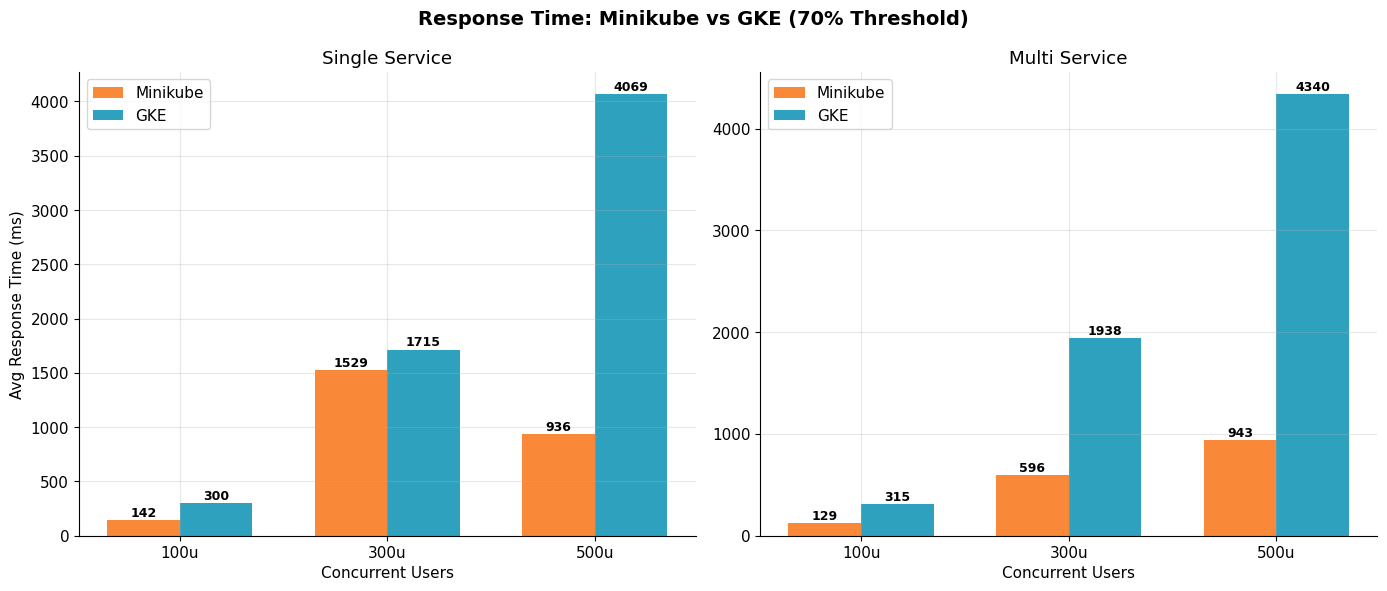

✅ Comparison 2


In [ ]:
# Comparison 2: Response Time
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Response Time: Minikube vs GKE (70% Threshold)', fontsize=14, fontweight='bold')
for col, scope in enumerate(scopes):
    ax = axes[col]; x = np.arange(3); w = 0.35
    mink = [minikube_df[(minikube_df['Threshold (%)']==70)&(minikube_df['Scope']==scope)&(minikube_df['Users']==u)]['Avg Response Time (ms)'].values[0] for u in user_levels]
    gke  = [gke_final_df[(gke_final_df['Threshold (%)']==70)&(gke_final_df['Scope']==scope)&(gke_final_df['Users']==u)]['Avg Response Time (ms)'].values[0] for u in user_levels]
    b1 = ax.bar(x-w/2, mink, w, label='Minikube', color=ENV_C['Minikube'], alpha=0.85)
    b2 = ax.bar(x+w/2, gke,  w, label='GKE',      color=ENV_C['GKE'],      alpha=0.85)
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+5, f'{int(h)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{scope} Service'); ax.set_xlabel('Concurrent Users')
    if col==0: ax.set_ylabel('Avg Response Time (ms)')
    ax.set_xticks(x); ax.set_xticklabels([f'{u}u' for u in user_levels])
    ax.legend()
plt.tight_layout()
plt.savefig('/content/graphs_comparison/comp2_response_time.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ Comparison 2")

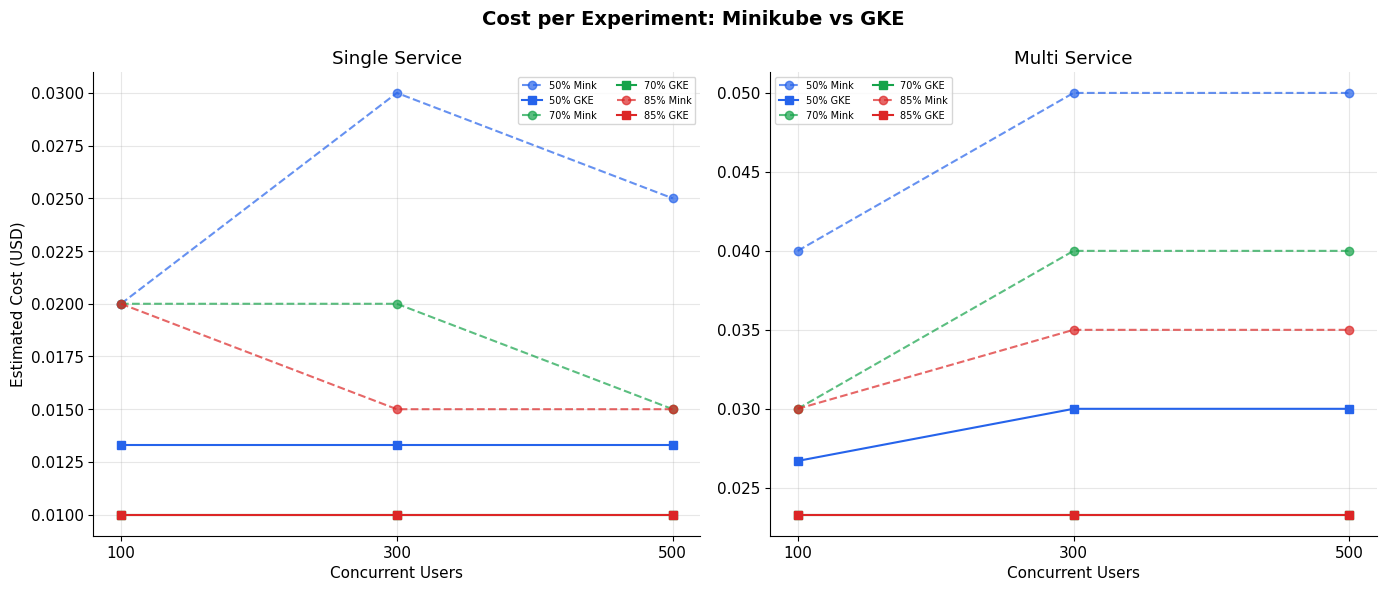

✅ Comparison 3


In [ ]:
# Comparison 3: Cost
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Cost per Experiment: Minikube vs GKE', fontsize=14, fontweight='bold')
for col, scope in enumerate(scopes):
    ax = axes[col]; x = np.arange(3); w = 0.35
    for i, t in enumerate(thresholds):
        mink = [minikube_df[(minikube_df['Threshold (%)']==t)&(minikube_df['Scope']==scope)&(minikube_df['Users']==u)]['Estimated Cost (USD)'].values[0] for u in user_levels]
        gke  = [gke_final_df[(gke_final_df['Threshold (%)']==t)&(gke_final_df['Scope']==scope)&(gke_final_df['Users']==u)]['Estimated Cost (USD)'].values[0] for u in user_levels]
        offset = (i-1)*0.28
        ax.plot(user_levels, mink, marker='o', linestyle='--', color=C[t], alpha=0.7, label=f'{t}% Mink')
        ax.plot(user_levels, gke,  marker='s', linestyle='-',  color=C[t], alpha=1.0, label=f'{t}% GKE')
    ax.set_title(f'{scope} Service'); ax.set_xlabel('Concurrent Users')
    if col==0: ax.set_ylabel('Estimated Cost (USD)')
    ax.set_xticks(user_levels); ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('/content/graphs_comparison/comp3_cost.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ Comparison 3")

/tmp/ipykernel_27201/660755470.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([mink_rt, gke_rt], labels=['Minikube', 'GKE'],


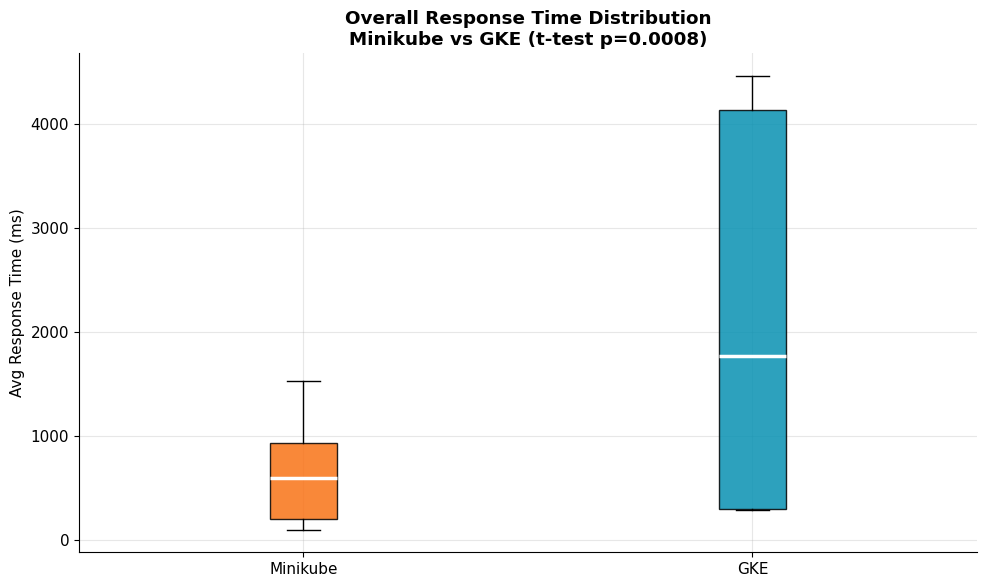

✅ Comparison 4


In [ ]:
# Comparison 4: Box plot summary
fig, ax = plt.subplots(figsize=(10, 6))
mink_rt = minikube_df['Avg Response Time (ms)'].values
gke_rt  = gke_final_df['Avg Response Time (ms)'].values
bp = ax.boxplot([mink_rt, gke_rt], labels=['Minikube', 'GKE'],
                patch_artist=True, medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], [ENV_C['Minikube'], ENV_C['GKE']]):
    patch.set_facecolor(color); patch.set_alpha(0.85)
t_stat, p_val = stats.ttest_ind(mink_rt, gke_rt)
ax.set_ylabel('Avg Response Time (ms)')
ax.set_title(f'Overall Response Time Distribution\nMinikube vs GKE (t-test p={p_val:.4f})', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/graphs_comparison/comp4_boxplot.png', dpi=180, bbox_inches='tight')
plt.show(); print("✅ Comparison 4")

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('/content/comp6910_graphs_gke', 'zip', '/content/graphs_gke')
files.download('/content/comp6910_graphs_gke.zip')

print("✅ GKE graphs downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ GKE graphs downloaded!


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'graphs_comparison', 'gke_results.xlsx', 'comp6910_graphs_comparison.zip', 'graphs_gke', 'complete_results.xlsx', 'comp6910_graphs_gke.zip', 'drive', 'sample_data']


In [ ]:
import shutil
from google.colab import files

# Zip the comparison graphs folder
shutil.make_archive('/content/comp6910_graphs_comparison', 'zip', '/content/graphs_comparison')

# Download
files.download('/content/comp6910_graphs_comparison.zip')

print("✅ All comparison graphs downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All comparison graphs downloaded!


In [ ]:
print("Content folder:", os.listdir('/content'))

Content folder: ['.config', 'graphs_comparison', 'gke_results.xlsx', 'comp6910_graphs_comparison.zip', 'graphs_gke', 'complete_results.xlsx', 'comp6910_graphs_gke.zip', 'drive', 'sample_data']


In [ ]:
import shutil
from google.colab import files

# -----------------------------
# Step 1: Define paths
# -----------------------------
SOURCE_FOLDER = '/content/graphs_comparison'
ZIP_NAME = 'comp6910_graphs_comparison'
LOCAL_ZIP_PATH = f'/content/{ZIP_NAME}.zip'
DRIVE_ZIP_PATH = f'/content/drive/MyDrive/comp6910/{ZIP_NAME}.zip'

# -----------------------------
# Step 2: Check folder exists
# -----------------------------
if not os.path.exists(SOURCE_FOLDER):
    print("❌ Folder not found:", SOURCE_FOLDER)
else:
    print("✅ Folder found:", SOURCE_FOLDER)

✅ Folder found: /content/graphs_comparison
